# Notebook 4: Spatial Classification
This notebook will contain code for classification through spatial analysis, harnessing CNN architectures such as ResNet for this task.

We're starting off with a model using just one band -> with index 102 corresponding to wavelength 668.8nm.

Here, we want to try and answer:
> Can spatial information compensate for reduced spectral information?

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler

import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes, closing, opening, disk

# --- Colab path setup ---

RUN_IN_COLAB = True   # set False locally

if RUN_IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    import sys
    from pathlib import Path

    THESIS_ROOT = Path("/content/drive/MyDrive/Masters/Thesis")
    DATASET_ROOT = THESIS_ROOT / "dataset"

    sys.path.append(str(THESIS_ROOT))

    print("Thesis root:", THESIS_ROOT)
    print("Dataset root:", DATASET_ROOT)
    print("hsi_utils path:", THESIS_ROOT / "hsi_utils.py")

from hsi_utils import load_data, load_cube, build_foreground_mask


In [2]:
SEED = 51

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # use gpu if available, otherwise cpu
device

device(type='cpu')

In [ ]:
# --- Colab / local data loading switch ---

RUN_IN_COLAB = True   # set False when running locally

if RUN_IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    import h5py
    from pathlib import Path

    DATASET_ROOT = Path("/content/drive/MyDrive/Masters/Thesis/dataset")
    HR_ROOT = DATASET_ROOT / "raw" / "FX10"

    print("Dataset root:", DATASET_ROOT)
    print("FX10 root:", HR_ROOT)

    if not HR_ROOT.exists():
        raise FileNotFoundError(f"Could not find FX10 folder at: {HR_ROOT}")

    all_files = list(HR_ROOT.rglob("*.hdf5"))
    print("Total .hdf5 files found:", len(all_files))

    df_files = pd.DataFrame({"filepath_FX10": all_files})
    df_files["sample_name"] = df_files["filepath_FX10"].apply(lambda p: p.stem)

    def resolve_valid_hdf5(path):
        try:
            with h5py.File(path, "r"):
                return path
        except Exception:
            return None

    df_files["resolved_path"] = df_files["filepath_FX10"].apply(resolve_valid_hdf5)
    df_valid = df_files[df_files["resolved_path"].notna()].copy()

    df_valid["variety"] = df_valid["sample_name"].str.split("_").str[0]
    df_valid["batch"] = df_valid["sample_name"].str.split("_").str[-1]
    df_valid["size"] = df_valid["batch"].str[0]
    df_valid["rep"] = df_valid["batch"].str[1:].astype(int)

    varieties = ["barley", "corn", "flax"]
    df_valid = df_valid[df_valid["variety"].isin(varieties)].copy()

    def assign_split(group):
        group = group.sort_values("rep").copy()
        group["split"] = "unused"
        group.iloc[:3, group.columns.get_loc("split")] = "train"
        group.iloc[3:4, group.columns.get_loc("split")] = "valid"
        group.iloc[4:5, group.columns.get_loc("split")] = "test"
        return group

    files_split = (
        df_valid
        .groupby(["variety", "size"], group_keys=False)
        .apply(assign_split)
        .reset_index(drop=True)
    )

    train_files = files_split[files_split["split"] == "train"].copy()
    valid_files = files_split[files_split["split"] == "valid"].copy()
    test_files = files_split[files_split["split"] == "test"].copy()

else:
    train_files, valid_files, test_files, files_split = load_data()
    varieties = ["barley", "corn", "flax"]

class_to_idx = {v: i for i, v in enumerate(varieties)}
idx_to_class = {i: v for v, i in class_to_idx.items()}

print("Train images:", len(train_files))
print("Valid images:", len(valid_files))
print("Test images:", len(test_files))

display(files_split[["sample_name", "variety", "size", "rep", "split"]].head())

In [ ]:
"""train_files, valid_files, test_files, files_split = load_data()

varieties = ["barley", "corn", "flax"]
class_to_idx = {v: i for i, v in enumerate(varieties)}
idx_to_class = {i: v for v, i in class_to_idx.items()}

print("Train images:", len(train_files))
print("Valid images:", len(valid_files))
print("Test images:", len(test_files))

display(files_split[["sample_name", "variety", "size", "rep", "split"]].head())"""

 Mounting E: into /mnt/e ...
[OK] Found dataset: /mnt/e/HSI_Dataset_2/Elements/data
 Removing old link /home/isaacmuscat/Grain-Variety-Classification/data_external
[OK] Linked /home/isaacmuscat/Grain-Variety-Classification/data_external -> /mnt/e/HSI_Dataset_2/Elements/data
Sample files:
   raw/calibration/FX10/calibration_1705a_0.hdf5
   raw/calibration/FX10/calibration_1705a_1.hdf5
   raw/calibration/FX10/calibration_1705a_2.hdf5
   raw/calibration/FX10/calibration_1705a_3.hdf5
   raw/calibration/FX10/calibration_1705_0.hdf5
   raw/calibration/FX10/calibration_1705_1.hdf5
   raw/calibration/FX10/calibration_1705_2.hdf5
   raw/calibration/FX10/calibration_1705_3.hdf5
   raw/calibration/Snapshot/processed/calibration_1705a_0/image_0000000003.hdr
   raw/calibration/Snapshot/processed/calibration_1705a_1/image_0000000000.hdr
ROOT:     /mnt/e/HSI_Dataset_2/Elements/data
Basepath: /mnt/e/HSI_Dataset_2/Elements/data/raw/FX10
OUTDIR:   /mnt/e/HSI_Dataset_2/Elements/data/processed/quickrun
To

/home/isaacmuscat/Grain-Variety-Classification/hsi_utils.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_split)


,sample_name,variety,size,rep,split
0,barley_l0,barley,l,0,train
1,barley_l1,barley,l,1,train
2,barley_l2,barley,l,2,train
3,barley_l3,barley,l,3,valid
4,barley_l4,barley,l,4,test


In [4]:
# From spectral_exploration.ipynb
# Top band index - 102
# Top wavelength - 668.8 nm

TARGET_WAVELENGTH = 668.8
PCA_BAND_INDEX = 102

print("Using PCA-selected band index:", PCA_BAND_INDEX)
print("Target wavelength:", TARGET_WAVELENGTH, "nm")

Using PCA-selected band index: 102
Target wavelength: 668.8 nm


In [ ]:
# we reduce the effect of extreme reflectance values and makes images more comparable across samples
def percentile_normalize(img, p_low=2, p_high=98):
    """
    Normalise one image to [0, 1] using robust percentiles.
    """
    lo, hi = np.percentile(img, [p_low, p_high])
    img = (img - lo) / (hi - lo + 1e-6)
    img = np.clip(img, 0, 1)
    return img.astype(np.float32)


def load_single_band_image(filepath, target_wavelength=668.8, crop=True, apply_mask=True):
    hcube, wlens, darkref, whiteref = load_cube(filepath)

    if crop:
        hcube = hcube[75:1025, 75:900, :]

    band_idx = int(np.argmin(np.abs(wlens - target_wavelength)))
    band_img = hcube[:, :, band_idx].astype(np.float32)

    if apply_mask:
        mask = build_foreground_mask(
            hcube,
            med_size=3,
            block_size=201,
            method="gaussian",
            offset=0.02,
            closing_radius=3,
            bin_iterations=2,
            min_size=1,
            area_threshold=50
        )
        band_img = band_img * mask

    band_img = percentile_normalize(band_img)

    return band_img, band_idx, wlens[band_idx]

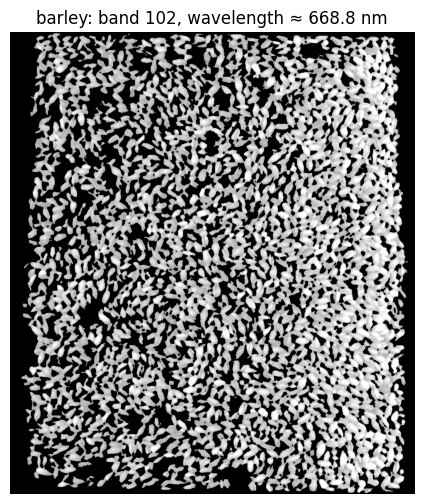

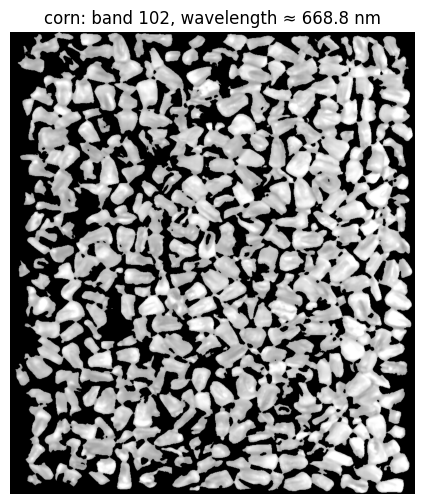

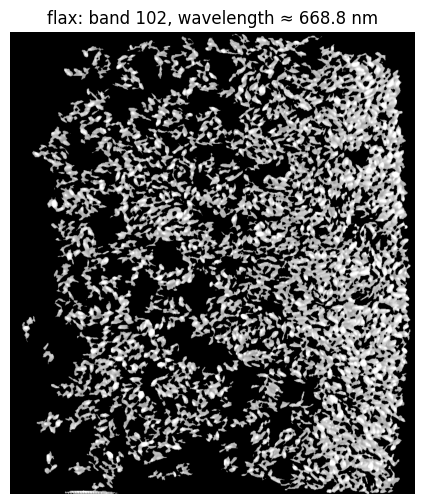

In [10]:
for var in varieties:
    subset = train_files[train_files["variety"] == var]

    if subset.empty:
        continue

    row = subset.iloc[0]
    img, band_idx, actual_wl = load_single_band_image(
        row["filepath_FX10"],
        target_wavelength=TARGET_WAVELENGTH
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"{var}: band {band_idx}, wavelength ≈ {actual_wl:.1f} nm")
    plt.axis("off")
    plt.show()

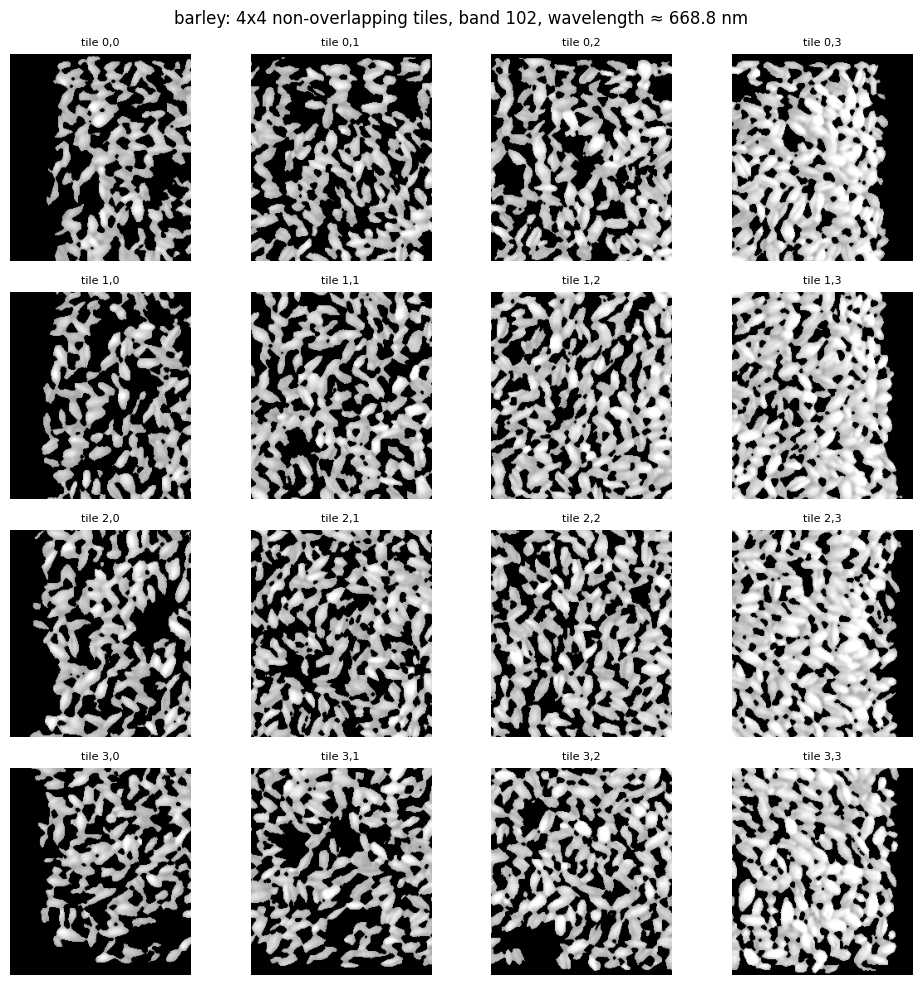

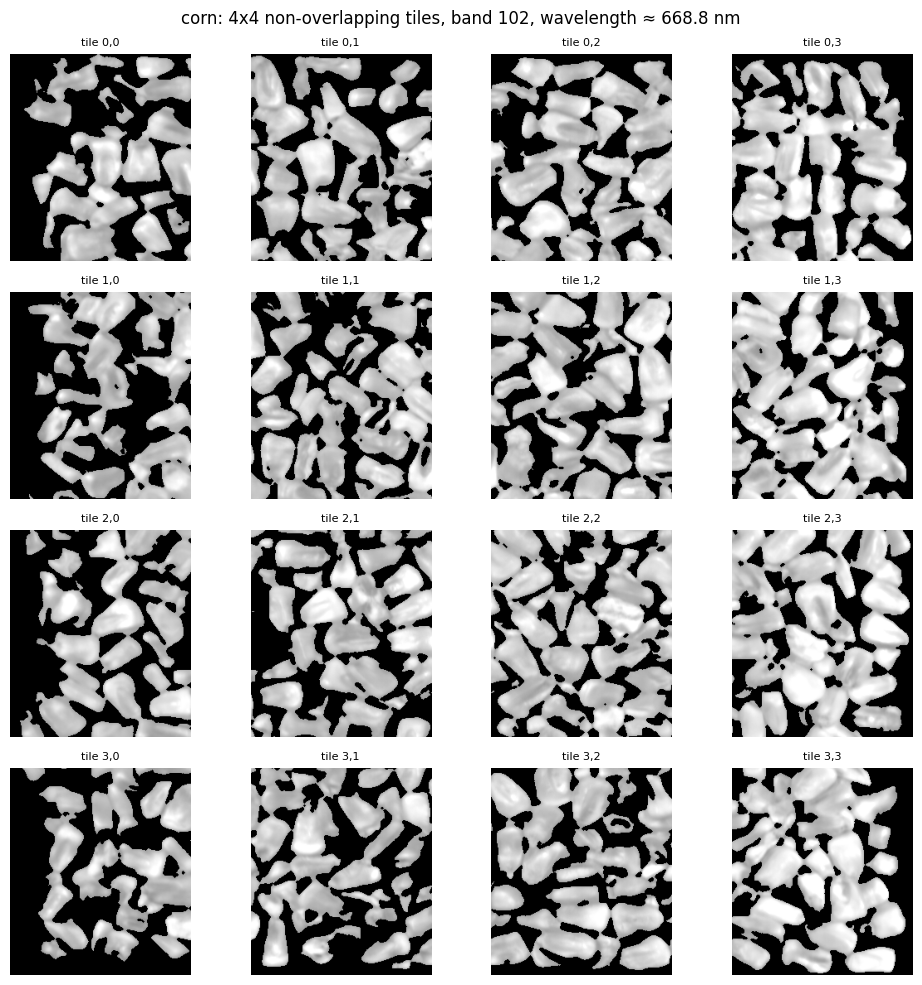

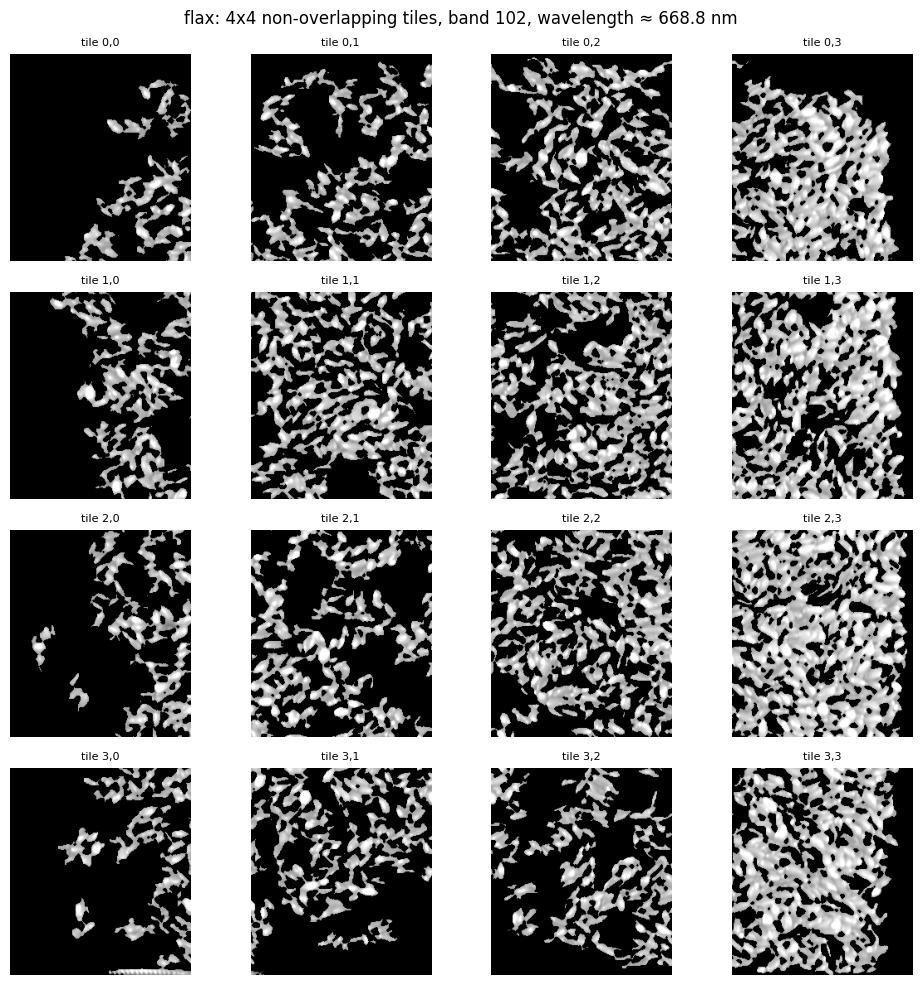

In [ ]:
# --- Visualise non-overlapping tiling ---
def make_non_overlapping_tiles(img, n_rows=4, n_cols=4):
    """
    Split one image into non-overlapping tiles - currently 4x4=16 tiles per image.
    """
    H, W = img.shape

    tile_h = H // n_rows
    tile_w = W // n_cols

    trimmed = img[:tile_h * n_rows, :tile_w * n_cols]

    tiles = []
    positions = []

    for r in range(n_rows):
        for c in range(n_cols):
            y0 = r * tile_h
            y1 = (r + 1) * tile_h
            x0 = c * tile_w
            x1 = (c + 1) * tile_w

            tile = trimmed[y0:y1, x0:x1]
            tiles.append(tile)
            positions.append((r, c, y0, y1, x0, x1))

    return tiles, positions


# Preview tiling on one image per class
for var in varieties:
    subset = train_files[train_files["variety"] == var]

    if subset.empty:
        continue

    row = subset.iloc[0]

    img, band_idx, actual_wl = load_single_band_image(
        row["filepath_FX10"],
        target_wavelength=TARGET_WAVELENGTH
    )

    tiles, positions = make_non_overlapping_tiles(img, n_rows=4, n_cols=4)

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))

    for ax, tile, pos in zip(axes.ravel(), tiles, positions):
        r, c, y0, y1, x0, x1 = pos
        ax.imshow(tile, cmap="gray")
        ax.set_title(f"tile {r},{c}", fontsize=8)
        ax.axis("off")

    plt.suptitle(f"{var}: 4x4 non-overlapping tiles, band {band_idx}, wavelength ≈ {actual_wl:.1f} nm")
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Dataset: each original image is split into non-overlapping tiles ---

class TiledSingleBandHSIDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_idx,
        target_wavelength=668.8,
        transform=None,
        crop=True,
        apply_mask=True,
        n_rows=4,
        n_cols=4
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.class_to_idx = class_to_idx
        self.target_wavelength = target_wavelength
        self.transform = transform
        self.crop = crop
        self.apply_mask = apply_mask
        self.n_rows = n_rows
        self.n_cols = n_cols

        self.tile_index = []

        self.image_cache = {}

        for image_idx in range(len(self.df)):
            for tile_idx in range(n_rows * n_cols):
                self.tile_index.append((image_idx, tile_idx))

    def __len__(self):
        return len(self.tile_index)

    def __getitem__(self, idx):
        image_idx, tile_idx = self.tile_index[idx]
        row = self.df.iloc[image_idx]

        # Cache the loaded/tiled image so the cube is not reloaded for every tile
        if image_idx not in self.image_cache:
            img, band_idx, actual_wl = load_single_band_image(
                row["filepath_FX10"],
                target_wavelength=self.target_wavelength,
                crop=self.crop,
                apply_mask=self.apply_mask
            )

            tiles, positions = make_non_overlapping_tiles(
                img,
                n_rows=self.n_rows,
                n_cols=self.n_cols
            )

            self.image_cache[image_idx] = tiles

        tile = self.image_cache[image_idx][tile_idx]

        img_uint8 = (tile * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_uint8, mode="L")

        if self.transform is not None:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = T.ToTensor()(img_pil)

        label = self.class_to_idx[row["variety"]]

        return img_tensor, label, image_idx

In [ ]:
"""# --- Dataset for no. of samples, how to load a sample and which label belongs to which sample ---

class SingleBandHSIDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_idx,
        target_wavelength=668.8,
        transform=None,
        crop=True,
        apply_mask=True
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.class_to_idx = class_to_idx
        self.target_wavelength = target_wavelength
        self.transform = transform
        self.crop = crop
        self.apply_mask = apply_mask

    def __len__(self):
        return len(self.df) # returns number of images

    def __getitem__(self, idx): # loads an image and a label
        row = self.df.iloc[idx] # gets a file

        img, band_idx, actual_wl = load_single_band_image(
            row["filepath_FX10"],
            target_wavelength=self.target_wavelength,
            crop=self.crop,
            apply_mask=self.apply_mask
        ) # load single band image

        # Convert [H, W] float image to PIL image
        img_uint8 = (img * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_uint8, mode="L") # convert to grayscale PIL image

        if self.transform is not None:
            img_tensor = self.transform(img_pil) # resizing, normalization etc.
        else:
            img_tensor = T.ToTensor()(img_pil)

        label = self.class_to_idx[row["variety"]] # returns numeric class label

        return img_tensor, label"""

Here, a custom PyTorch Dataset was created because the data is not in the form of ordinary PNG files.

Each sample must be:
* Loaded from an HSI cube
* Reduced to the selected wavelength
* Masked
* Normalized 
* Transformed
* and paired with a label. 

This is the standard way to handle custom datasets in PyTorch.

In [ ]:
#IMG_SIZE = 224
#BATCH_SIZE = 8

BATCH_SIZE_IMAGES = 1   # one full image worth of tiles per batch
N_ROWS = 4
N_COLS = 4
USE_SUBSET = True

# No augmentations for now
train_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

if USE_SUBSET:
    train_files_run = (
        train_files
        .sort_values(["variety", "size", "rep"])
        .groupby("variety", group_keys=False)
        .head(2)
        .reset_index(drop=True)
    )

    valid_files_run = (
        valid_files
        .sort_values(["variety", "size", "rep"])
        .groupby("variety", group_keys=False)
        .head(1)
        .reset_index(drop=True)
    )

    test_files_run = (
        test_files
        .sort_values(["variety", "size", "rep"])
        .groupby("variety", group_keys=False)
        .head(1)
        .reset_index(drop=True)
    )
else:
    train_files_run = train_files.reset_index(drop=True)
    valid_files_run = valid_files.reset_index(drop=True)
    test_files_run = test_files.reset_index(drop=True)


train_dataset = TiledSingleBandHSIDataset(
    train_files_run,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=train_transform,
    n_rows=N_ROWS,
    n_cols=N_COLS
)

valid_dataset = TiledSingleBandHSIDataset(
    valid_files_run,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=eval_transform,
    n_rows=N_ROWS,
    n_cols=N_COLS
)

test_dataset = TiledSingleBandHSIDataset(
    test_files_run,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=eval_transform,
    n_rows=N_ROWS,
    n_cols=N_COLS
)


class ImageGroupedBatchSampler(Sampler):
    def __init__(self, dataset, shuffle=True):
        self.dataset = dataset
        self.shuffle = shuffle

        self.groups = {}
        for dataset_idx, (image_idx, tile_idx) in enumerate(dataset.tile_index):
            self.groups.setdefault(image_idx, []).append(dataset_idx)

        self.image_indices = list(self.groups.keys())

    def __iter__(self):
        image_indices = self.image_indices.copy()

        if self.shuffle:
            random.shuffle(image_indices)

        for image_idx in image_indices:
            yield self.groups[image_idx]

    def __len__(self):
        return len(self.image_indices)
    

train_loader = DataLoader(
    train_dataset,
    batch_sampler=ImageGroupedBatchSampler(train_dataset, shuffle=True)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_sampler=ImageGroupedBatchSampler(valid_dataset, shuffle=False)
)

test_loader = DataLoader(
    test_dataset,
    batch_sampler=ImageGroupedBatchSampler(test_dataset, shuffle=False)
)

print("Train tiles:", len(train_dataset))
print("Valid tiles:", len(valid_dataset))
print("Test tiles:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train tiles: 432
Valid tiles: 144
Test tiles: 144
Train batches: 54
Valid batches: 18
Test batches: 18


In [ ]:
"""IMG_SIZE = 224 # typical size for resnet architectures
BATCH_SIZE = 8

train_transform = T.Compose([ 
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
]) # the actions taken here are augmentations -> artificially varying the training images so that we reduce overfitting; only for train set

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = SingleBandHSIDataset(
    train_files,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=train_transform
)

valid_dataset = SingleBandHSIDataset(
    valid_files,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=eval_transform
)

test_dataset = SingleBandHSIDataset(
    test_files,
    class_to_idx,
    target_wavelength=TARGET_WAVELENGTH,
    transform=eval_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # feeds data into model in mini-batches
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))"""

NameError: name 'SingleBandHSIDataset' is not defined

In [15]:
def build_resnet18_1channel(num_classes=3):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    # Convert pretrained RGB conv1 weights to 1-channel by averaging over RGB channels
    old_conv = model.conv1

    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

    model.conv1 = new_conv

    # Replace final classification layer for 3 grain classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


model = build_resnet18_1channel(num_classes=len(varieties)).to(device)
model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/isaacmuscat/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 16.8MB/s]


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
"""def build_resnet18_1channel(num_classes=3):
    model = resnet18(weights=None) # creates resnet without pretraining

    # change first convolution from RGB input to 1-channel input
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # replace final classification layer - we want to predict just 3 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


model = build_resnet18_1channel(num_classes=len(varieties)).to(device)
model"""

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
criterion = nn.CrossEntropyLoss() # loss for multi-class classification

# adam optimizer typical for updating model weights -> adapts learning rate per parameter + better weight decay handling
optimizer = torch.optim.AdamW( 
    model.parameters(),
    lr=1e-4, # small learning rate -> small dataset so we're a bit more conservative with this choice
    weight_decay=1e-4 
) 

# scheduler lowers learning rate if valid. loss stops improving; helps training settle instead of continuing with an inflated LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [ ]:
# --- handling training + validation ---
def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval() # gradients not computed -> validation

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels, image_idxs in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

In [ ]:
EPOCHS = 5
PATIENCE = 1

best_valid_loss = np.inf
best_model_state = None
epochs_without_improvement = 0

history = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer=optimizer)
    valid_loss, valid_acc = run_one_epoch(model, valid_loader, optimizer=None)

    scheduler.step(valid_loss) # update LR if needed

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f}, train acc={train_acc:.3f} | "
        f"valid loss={valid_loss:.4f}, valid acc={valid_acc:.3f}"
    )

    if valid_loss < best_valid_loss: # keep best valid. loss state
        best_valid_loss = valid_loss
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_state)

,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.040918,0.444444,1.015418,0.444444
1,2,0.675116,0.629630,1.045122,0.555556
2,3,0.758805,0.740741,1.488288,0.444444


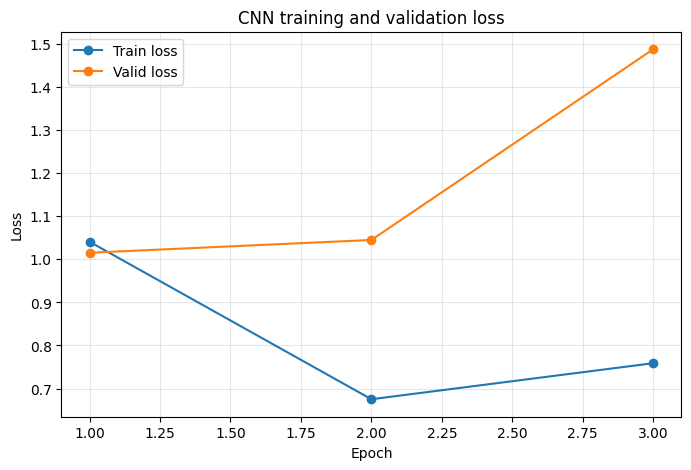

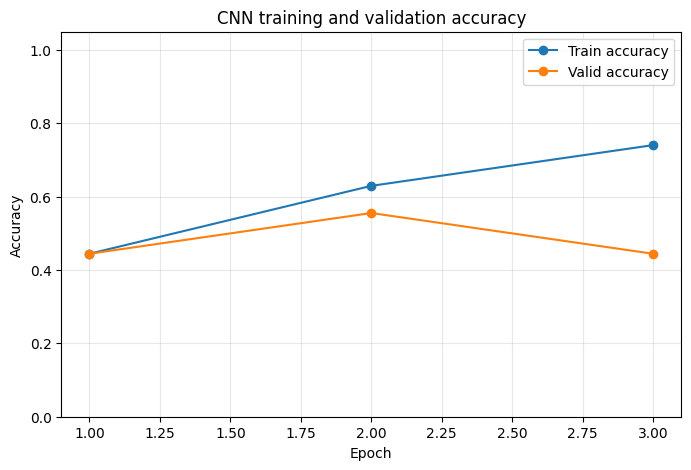

In [ ]:
history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], marker="o", label="Valid loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], marker="o", label="Valid accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN training and validation accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training is improving but validation is getting worse -> overfitting!!

In [ ]:
def predict(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, image_idxs in loader:            
            images = images.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = predict(model, test_loader)

test_acc = accuracy_score(y_true, y_pred)

print("Test accuracy:", round(test_acc, 4))
print()
print(classification_report(
    y_true,
    y_pred,
    target_names=varieties
))

Test accuracy: 0.4444

              precision    recall  f1-score   support

      barley       0.00      0.00      0.00         3
        corn       1.00      0.33      0.50         3
        flax       0.38      1.00      0.55         3

    accuracy                           0.44         9
   macro avg       0.46      0.44      0.35         9
weighted avg       0.46      0.44      0.35         9



/home/isaacmuscat/Grain-Variety-Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isaacmuscat/Grain-Variety-Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/isaacmuscat/Grain-Variety-Classification/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

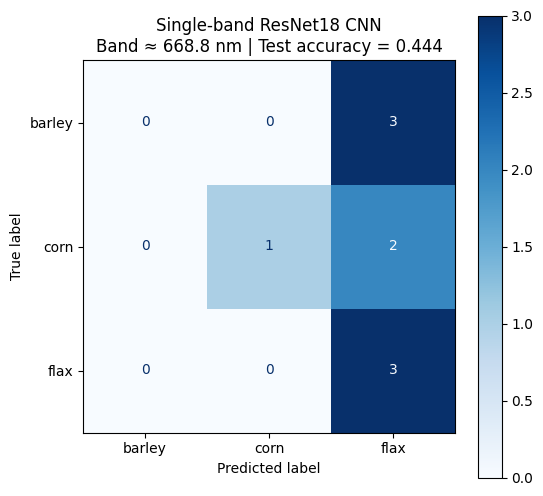

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=varieties
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(
    f"Single-band ResNet18 CNN\n"
    f"Band ≈ {TARGET_WAVELENGTH} nm | Test accuracy = {test_acc:.3f}"
)
plt.show()

In [ ]:
SAVE_PATH = "spatial_resnet18_single_band_668nm.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "target_wavelength": TARGET_WAVELENGTH,
    "pca_band_index": PCA_BAND_INDEX,
    "history": history
}, SAVE_PATH)

print("Saved model to:", SAVE_PATH)

Saved model to: spatial_resnet18_single_band_668nm.pt
